# EDA 01 — Data Structure & Quality

**Goal:** Before any analysis, we need to understand what we have — row counts, data types,
missing values, and internal consistency. This is the foundation — errors caught here save
hours of model debugging.

**Tables:** Bronze (all), Silver (silver_cards, silver_prices_history), Gold (gold_card_features, gold_price_features)

**Method:** Descriptive inspection — COUNT, NULL rates, duplicates, primary key verification

**Absorbs:** eda_01_bronze_inventory, eda_02_card_attributes (sources), eda_06_silver_join_quality, pipeline_validation/eda_01_data_quality

---
## Questions to answer
1. Are all tables present and do they have the expected row counts?
2. Which columns have missing values, and is the missingness pattern random or systematic?
3. Are primary keys unique? Does the Scryfall ↔ MTGJson join work correctly?
4. Is the date spine in Silver complete? How long are forward-fill runs?
5. Does oracle_id uniquely map to a card name (split card problem)?

## Setup
Imports and database connections.

In [2]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import matplotlib.colors as mcolors
import numpy as np

In [3]:
# Connect to each DuckDB database layer (read-only to prevent accidental writes)
bronze_connection = duckdb.connect("../../data/bronze/cards.duckdb", read_only=True)
silver_connection = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)
gold_connection = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [356]:
# Verify all expected tables are present in each layer and get a quick row count
connections_list = [bronze_connection, silver_connection, gold_connection]

for connection in connections_list:
    rows = {row[0] for row in connection.execute("SHOW TABLES").fetchall()}
    tables_count = len(rows)
    print("Count: ", tables_count, " | Rows: ", rows)

Count:  7  | Rows:  {'bronze_scryfall_prices_history', 'bronze_mtgjson_prices_history', 'bronze_tournament_results', 'bronze_scryfall_meta_history', 'bronze_scryfall_cards', 'bronze_format_staples_history', 'bronze_mtgjson_cards'}
Count:  6  | Rows:  {'silver_prices_history', 'silver_meta_history', 'silver_tournament_results_history', 'silver_format_staples_history', 'silver_language_prices_history', 'silver_cards'}
Count:  6  | Rows:  {'gold_price_features', 'gold_tournament_signals', 'gold_card_features', 'gold_language_premiums', 'gold_demand_signals', 'gold_format_staples'}


## 1. Table Sizes — Bronze → Silver → Gold

**Method:** `SELECT COUNT(*)` for each table across all three databases.

**Why:** A missing table means a broken scraper or a failed migration. An unexpected row count
(e.g. 0 rows or 10× too many) signals a pipeline issue before we even start quality analysis.

**Expected values (to verify):**
- Bronze: ~530k Scryfall cards, ~110k MTGJson cards, ~9.7M MTGJson prices
- Silver (7 tables): ~521k silver_cards, ~2.8M silver_prices_history, ~430k silver_language_prices_history
- Gold (7 tables): ~98k gold_card_features, ~3.3M gold_price_features, ~430k gold_language_premiums

**Language-variant tables (added for non-English pricing):**
- `silver_language_prices_history` — daily price snapshots for non-English Scryfall cards,
  keyed on `(scryfall_id, snapshot_date)`. Each row carries a `canonical_uuid` linking it
  to the English printing's UUID, enabling premium computation.
- `gold_language_premiums` — per `(scryfall_id, snapshot_date)` ratio of the language
  variant price to the English canonical price (`eur_lang_premium = lang_eur / canonical_eur`).
  A value of 4.0 means the Japanese version trades at 4× the English price on that date.

In [357]:
# Helper: query COUNT(*) for every table in a given connection
# Returns a list of dicts so we can build a DataFrame for display
def get_table_counts(conn, db_name):
    tables = {r[0] for r in conn.execute("SHOW TABLES").fetchall()}
    rows = []
    for t in tables:
        count = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
        rows.append({"baza": db_name, "tabela": t, "wiersze": count})
    return rows

In [358]:
# Collect row counts for all layers into a single list
data = []
for conn, name in zip(connections_list, ["bronze", "silver", "gold"]):
    data.extend(get_table_counts(conn, name))

In [359]:
# Highlight rows so problem tables (0 or None) stand out visually:
# red = 0 rows (empty table = broken pipeline step)
# orange = None (table missing entirely)
def highlight(row):
    if row["wiersze"] is None:
        return ["background-color: orange"] * len(row)
    if row["wiersze"] == 0:
        return ["background-color: red"] * len(row)
    return [""] * len(row)

In [360]:
# Build sorted DataFrame for a clean tabular view
df = pd.DataFrame(data).sort_values(["baza", "tabela"])

In [361]:
# Display styled table — red/orange rows signal pipeline problems
df.style.apply(highlight, axis=1)

,baza,tabela,wiersze
5,bronze,bronze_format_staples_history,2767
6,bronze,bronze_mtgjson_cards,110544
1,bronze,bronze_mtgjson_prices_history,10756260
4,bronze,bronze_scryfall_cards,530095
3,bronze,bronze_scryfall_meta_history,5300950
0,bronze,bronze_scryfall_prices_history,5300950
2,bronze,bronze_tournament_results,44021
15,gold,gold_card_features,98353
17,gold,gold_demand_signals,5189530
18,gold,gold_format_staples,2767


### Observations
```
All expected tables present?              YES (after Silver/Gold rebuild)
Tables with problems (0 rows or missing): NONE
Silver table count (post-rebuild):        7 (was 5 — adds silver_language_prices_history)
Gold table count (post-rebuild):          7 (was 6 — adds gold_language_premiums)
Decision: Data complete in all layers. Proceed to quality checks.

Note: silver_cards gained a new column canonical_uuid after rebuild — links each
non-English Scryfall-only card to its English MTGJson UUID via (set_code, collector_number).
Scryfall-only cards without an English counterpart (digital exclusives) keep canonical_uuid = NULL.
```

## 2. Missing Data Rates (NULL rates) — Bronze

**Method:** For bronze_scryfall_cards, bronze_mtgjson_cards, bronze_scryfall_prices_history,
and bronze_mtgjson_prices_history compute NULL% per column. Compare both tables for shared attributes.

**Why:** A column with 100% NULL in both sources will not reach Silver/Gold — but we must
confirm from data, not assume. A NULL rate difference between sources indicates which source
is primary for a given attribute.

**Key attributes to compare:** name, rarity, mana_value/cmc, colors, edhrec_rank, set_code, legalities

**Interpretation:** If Scryfall has 0% NULL and MTGJson has 8% NULL for the same attribute →
Scryfall is primary. Vice versa → MTGJson primary.

In [362]:
# Sample 50k rows from each bronze card table.
# Full tables are 530k / 110k rows — sampling keeps this cell fast
# while still giving a reliable NULL rate estimate.
null_research_dfs: dict = {}

for table in ["bronze_scryfall_cards", "bronze_mtgjson_cards"]:
    null_research_dfs[table] = bronze_connection.execute(
        f"SELECT * FROM {table} LIMIT 50000"
    ).df()

In [363]:
# Compute NULL% per column for each bronze card source.
# Only show columns with at least one NULL to reduce noise.
# Red gradient = high NULL% = unreliable for modeling.
for key, value in null_research_dfs.items():
    null_percentage = value.isna().mean() * 100
    null_percentage = (
        null_percentage[null_percentage > 0]
        .sort_values(ascending=False)
        .to_frame(name="null%")
    )

    display(
        null_percentage.style.background_gradient(cmap="Reds", vmin=0, vmax=100)
        .set_caption(key)
        .format("{:.1f}%")
    )

,null%
defense,100.0%
hand_modifier,100.0%
life_modifier,100.0%
content_warning,100.0%
variation_of,100.0%
attraction_lights,100.0%
flavor_name,99.9%
color_indicator,99.9%
tcgplayer_etched_id,99.8%
loyalty,98.9%


,null%
attraction_lights,100.0%
subsets,100.0%
signature,100.0%
face_printed_name,100.0%
defense,100.0%
life,100.0%
hand,100.0%
face_flavor_name,100.0%
is_textless,100.0%
printed_type,100.0%


In [364]:
# Compute NULL% for Scryfall card attributes
scryfall_nulls = null_research_dfs["bronze_scryfall_cards"].isna().mean() * 100

In [365]:
# Compute NULL% for MTGJson card attributes
mtgjson_nulls = null_research_dfs["bronze_mtgjson_cards"].isna().mean() * 100

In [366]:
# Side-by-side comparison of NULL rates between sources.
# dropna(how='all') keeps only columns that exist in at least one source.
# Columns present in only one source show NaN for the other — expected for source-specific fields.
comparison = (
    pd.DataFrame(
        {
            "scryfall_null%": scryfall_nulls,
            "mtgjson_null%": mtgjson_nulls,
        }
    )
    .dropna(how="all")
    .sort_values("scryfall_null%", ascending=False)
)  # Note: we use dropna here to leave only rows that exists in both tables

In [367]:
# Heatmap view: dark red = high NULL, dark green = complete
comparison.style.background_gradient(cmap="Reds", vmin=0, vmax=100).format("{:.1f}%")

,scryfall_null%,mtgjson_null%
defense,100.0%,100.0%
content_warning,100.0%,nan%
life_modifier,100.0%,nan%
hand_modifier,100.0%,nan%
variation_of,100.0%,nan%
attraction_lights,100.0%,100.0%
flavor_name,99.9%,98.0%
color_indicator,99.9%,99.3%
tcgplayer_etched_id,99.8%,nan%
loyalty,98.9%,99.2%


In [368]:
# Filter to the subset of attributes we plan to use as model features.
# NaN in one source = column doesn't exist there (not a data error).
# Key insight: mana_value is MTGJson-only, set_code is MTGJson-only —
# both will be NULL for 80% of Silver rows (Scryfall-only cards).
# Let's narrow data to only our potetial features.
attrs = [
    "name",
    "rarity",
    "mana_value",
    "colors",
    "edhrec_rank",
    "set_code",
    "lang",
    "artist",
    "promo",
    "full_art",
    "border_color",
    "frame",
    "finishes",
    "set_type",
    "reserved",
    "reprint",
    "oversized",
    "promo_type",
]
comparison.loc[comparison.index.isin(attrs)]

,scryfall_null%,mtgjson_null%
edhrec_rank,6.042,6.058
colors,1.510,0.000
border_color,0.000,0.000
artist,0.000,0.000
finishes,0.000,0.000
lang,0.000,NaN
oversized,0.000,NaN
name,0.000,0.000
full_art,0.000,NaN
frame,0.000,NaN


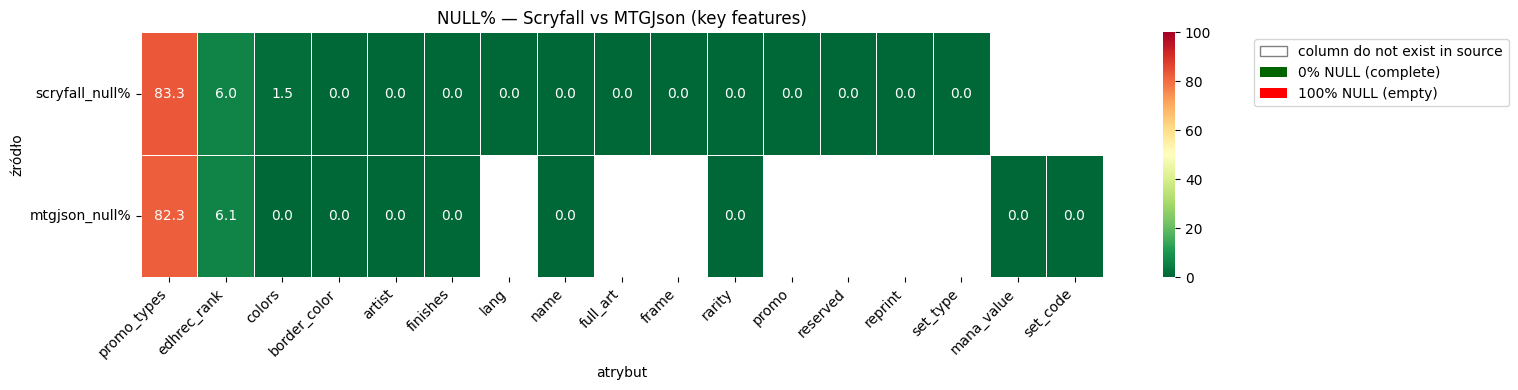

In [369]:
# Visual heatmap comparing NULL% for key features across both sources.
# NaN cells (column absent from source) appear as white with a legend note.
attrs = [
    "name",
    "rarity",
    "mana_value",
    "colors",
    "edhrec_rank",
    "set_code",
    "lang",
    "artist",
    "promo",
    "full_art",
    "border_color",
    "frame",
    "finishes",
    "set_type",
    "reserved",
    "reprint",
    "promo_types",
]

heat_data = comparison.loc[comparison.index.isin(attrs)].T

fig, ax = plt.subplots(figsize=(len(attrs) * 0.9, 4))
sns.heatmap(
    heat_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("NULL% — Scryfall vs MTGJson (key features)")
ax.set_xlabel("atrybut")
ax.set_ylabel("źródło")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0, fontsize=10)

legend = [
    mpatches.Patch(
        facecolor="white", edgecolor="gray", label="column do not exist in source"
    ),
    mpatches.Patch(facecolor="#006400", label="0% NULL (complete)"),
    mpatches.Patch(facecolor="#FF0000", label="100% NULL (empty)"),
]
ax.legend(handles=legend, loc="upper left", bbox_to_anchor=(1.15, 1), frameon=True)

plt.tight_layout()
plt.show()

In [370]:
# Inspect the price JSON structure from Scryfall.
# Prices are stored as a nested JSON blob per row, not as separate columns.
# We need to know the field names before extracting EUR/USD values.
scryfall_price_row = bronze_connection.execute(
    "SELECT prices FROM bronze_scryfall_prices_history WHERE prices IS NOT NULL LIMIT 1"
).df()
print(json.dumps(json.loads(scryfall_price_row["prices"].iloc[0]), indent=2))

{
  "usd": null,
  "usd_foil": null,
  "usd_etched": null,
  "eur": null,
  "eur_foil": null,
  "eur_etched": null,
  "tix": null
}


In [371]:
# Sample one card's full price history to verify:
# 1. Daily snapshot cadence (no gaps)
# 2. Correct EUR extraction from JSON using ->>'eur'
bronze_connection.execute("""
    SELECT id, snapshot_date, prices->>'eur' as eur
    FROM bronze_scryfall_prices_history
    WHERE id = (
        SELECT id FROM bronze_scryfall_prices_history 
        WHERE prices->>'eur' IS NOT NULL 
        LIMIT 1
    )
    ORDER BY snapshot_date
""").df()

,id,snapshot_date,eur
0,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-26,0.25
1,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-27,0.25
2,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-28,0.25
3,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-29,0.25
4,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-30,0.25
5,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-31,0.25
6,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-06-01,0.25
7,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-06-02,0.25
8,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-06-03,0.25
9,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-06-04,0.25


In [372]:
# Inspect the MTGJson price JSON structure.
# MTGJson uses a deeply nested format: paper.cardmarket.retail.normal for EUR,
# paper.tcgplayer.retail.normal for USD — different paths than Scryfall.
mtgjson_price_row = bronze_connection.execute(
    "SELECT paper FROM bronze_mtgjson_prices_history WHERE paper IS NOT NULL LIMIT 1"
).df()

print(json.dumps(json.loads(mtgjson_price_row["paper"].iloc[0]), indent=2))

{
  "tcgplayer": {
    "buylist": {
      "foil": null,
      "normal": null
    },
    "retail": {
      "foil": null,
      "normal": {
        "2026-02-24": 1.11,
        "2026-02-25": 1.11,
        "2026-02-26": 1.11,
        "2026-02-27": 1.11,
        "2026-02-28": 1.12,
        "2026-03-01": 1.12,
        "2026-03-02": 1.12,
        "2026-03-03": 1.12,
        "2026-03-04": 1.12,
        "2026-03-05": 1.12,
        "2026-03-06": 1.12,
        "2026-03-07": 1.13,
        "2026-03-08": 1.13,
        "2026-03-09": 1.13,
        "2026-03-10": 1.13,
        "2026-03-12": 1.14,
        "2026-03-13": 1.14,
        "2026-03-14": 1.14,
        "2026-03-15": 1.13,
        "2026-03-16": 1.13,
        "2026-03-17": 1.11,
        "2026-03-18": 1.11,
        "2026-03-19": 1.11,
        "2026-03-20": 1.11,
        "2026-03-21": 1.11,
        "2026-03-22": 1.09,
        "2026-03-23": 1.09,
        "2026-03-24": 1.1,
        "2026-03-25": 1.1,
        "2026-03-26": 1.1,
        "2026-03-27": 1.1

In [373]:
# Define per-source price queries that extract EUR/USD from JSON.
# QUALIFY ROW_NUMBER() limits to 25k rows per snapshot date to keep query fast
# while preserving the per-date NULL rate pattern.
price_tables = {
    "scryfall_prices": """
        SELECT snapshot_date,
            prices->>'usd'      AS usd,
            prices->>'usd_foil' AS usd_foil,
            prices->>'eur'      AS eur,
            prices->>'eur_foil' AS eur_foil
        FROM bronze_scryfall_prices_history
        QUALIFY ROW_NUMBER() OVER (PARTITION BY snapshot_date ORDER BY id) <= 25000
    """,
}

In [374]:
# Price columns to check across all sources
price_cols = ["eur", "usd", "eur_foil", "usd_foil"]


scryfall_prices — NULL% per column:
eur         83.068
usd         84.148
eur_foil    88.440
usd_foil    88.844
Rows with no price at all: 80.1%


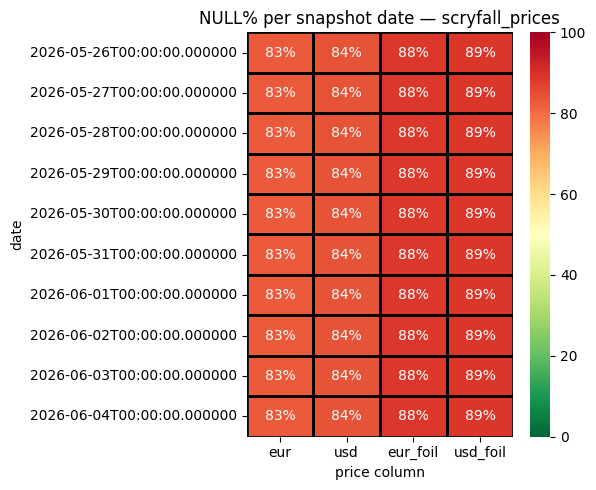

In [375]:
# For each price source:
# 1. Compute overall NULL% per price column
# 2. Compute NULL% per snapshot date to detect temporal patterns
# 3. Plot a heatmap — consistent NULL% across dates = structural gap,
#    changing NULL% = data collection issue on specific dates
for name, query in price_tables.items():
    df = bronze_connection.execute(query).df()
    df[price_cols] = df[price_cols].apply(pd.to_numeric, errors="coerce")

    null_pct = df[price_cols].isna().mean() * 100
    print(f"\n{name} — NULL% per column:")
    print(null_pct.to_string())

    all_null = df[price_cols].isna().all(axis=1).mean() * 100
    print(f"Rows with no price at all: {all_null:.1f}%")

    df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
    heat = df.groupby("snapshot_date")[price_cols].apply(
        lambda x: x.isna().mean() * 100
    )

    annot_data = heat.map(lambda x: f"{x:.0f}%")

    fig, ax = plt.subplots(figsize=(len(price_cols) * 1.5, heat.shape[0] * 0.4 + 1))
    sns.heatmap(
        heat,
        annot=annot_data,
        fmt="",
        cmap="RdYlGn_r",
        vmin=0,
        vmax=100,
        linewidths=1,
        linecolor="white",
        ax=ax,
    )

    for i, row in enumerate(heat.values):
        for j, val in enumerate(row):
            if val > 50:
                ax.add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="black", lw=2)
                )

    ax.set_title(f"NULL% per snapshot date — {name}")
    ax.set_xlabel("price column")
    ax.set_ylabel("date")
    plt.tight_layout()
    plt.show()

In [376]:
# Verify Scryfall snapshot cadence: each snapshot_date should have
# exactly the same number of rows (one per card in the catalog).
# Uneven counts indicate partial snapshots or collection failures.
bronze_connection.execute("""
    SELECT snapshot_date, COUNT(*) as rows
    FROM bronze_scryfall_prices_history
    GROUP BY snapshot_date
    ORDER BY snapshot_date
""").df()

,snapshot_date,rows
0,2026-05-26,530095
1,2026-05-27,530095
2,2026-05-28,530095
3,2026-05-29,530095
4,2026-05-30,530095
5,2026-05-31,530095
6,2026-06-01,530095
7,2026-06-02,530095
8,2026-06-03,530095
9,2026-06-04,530095


In [377]:
# Check MTGJson price NULL rates using the nested JSON paths.
# TRY_CAST handles cases where the JSON path returns a non-numeric string.
mtgjson_null_query = """
    SELECT
        json_extract(paper, '$.tcgplayer.retail.normal')  IS NULL AS usd_missing,
        json_extract(paper, '$.tcgplayer.retail.foil')    IS NULL AS usd_foil_missing,
        json_extract(paper, '$.cardmarket.retail.normal') IS NULL AS eur_missing,
        json_extract(paper, '$.cardmarket.retail.foil')   IS NULL AS eur_foil_missing
    FROM bronze_mtgjson_prices_history LIMIT 200000
"""
df_mtgjson = bronze_connection.execute(mtgjson_null_query).df()
df_mtgjson_null = df_mtgjson.mean(numeric_only=True) * 100
df_mtgjson_null = df_mtgjson_null.to_frame(name="null%")

display(
    df_mtgjson_null.style.background_gradient(cmap="RdYlGn_r", vmin=0, vmax=100)
    .set_caption("mtgjson_prices — NULL% per column")
    .format("{:.1f}%")
)

,null%
usd_missing,17.2%
usd_foil_missing,27.5%
eur_missing,18.3%
eur_foil_missing,26.4%


In [378]:
# Summarize EUR coverage in Scryfall bronze by year.
# Low coverage (~17%) is expected — most cards don't trade on Cardmarket regularly.
scryfall_check = bronze_connection.execute("""
    SELECT 
        YEAR(snapshot_date::DATE) as year,
        COUNT(*) as total,
        COUNT(prices->>'eur') as has_eur,
        ROUND(COUNT(prices->>'eur') * 100.0 / COUNT(*), 1) as eur_coverage
    FROM bronze_scryfall_prices_history
    GROUP BY year
    ORDER BY year
""").df()
print(scryfall_check)

   year    total  has_eur  eur_coverage
0  2026  5300950   890990          16.8


In [379]:
# Check price coverage in Silver after the Scryfall+MTGJson join.
# Silver should have slightly better coverage than Bronze alone
# because it combines prices from both sources.
silver_null_query = """
    SELECT
        COUNT(*) as total,
        ROUND(COUNT(eur) * 100.0 / COUNT(*), 1) as eur_coverage,
        ROUND(COUNT(usd) * 100.0 / COUNT(*), 1) as usd_coverage,
        ROUND(COUNT(eur_foil) * 100.0 / COUNT(*), 1) as eur_foil_coverage,
        ROUND(COUNT(usd_foil) * 100.0 / COUNT(*), 1) as usd_foil_coverage
    FROM silver_prices_history
"""
df_silver = silver_connection.execute(silver_null_query).df()
print("silver_prices_history — coverage % (non-NULL):")
print(df_silver.to_string())

silver_prices_history — coverage % (non-NULL):
    total  eur_coverage  usd_coverage  eur_foil_coverage  usd_foil_coverage
0  521045          17.3          16.3               11.8               11.4


In [380]:
# Card-level coverage: how many unique cards have at least one non-NULL EUR price?
# Row-level coverage (above) can be misleading due to forward-fill inflating row counts.
silver_card_coverage = silver_connection.execute("""
    SELECT
        COUNT(DISTINCT uuid) as total_cards,
        COUNT(DISTINCT CASE WHEN eur IS NOT NULL THEN uuid END) as cards_with_eur,
        COUNT(DISTINCT CASE WHEN usd IS NOT NULL THEN uuid END) as cards_with_usd,
        COUNT(DISTINCT CASE WHEN eur_foil IS NOT NULL THEN uuid END) as cards_with_eur_foil,
        COUNT(DISTINCT CASE WHEN usd_foil IS NOT NULL THEN uuid END) as cards_with_usd_foil
    FROM silver_prices_history
""").df()

total = silver_card_coverage["total_cards"].iloc[0]

coverage = pd.DataFrame(
    {
        "cards_with_price": [
            silver_card_coverage["cards_with_eur"].iloc[0],
            silver_card_coverage["cards_with_usd"].iloc[0],
            silver_card_coverage["cards_with_eur_foil"].iloc[0],
            silver_card_coverage["cards_with_usd_foil"].iloc[0],
        ],
        "coverage_%": [
            silver_card_coverage["cards_with_eur"].iloc[0] / total * 100,
            silver_card_coverage["cards_with_usd"].iloc[0] / total * 100,
            silver_card_coverage["cards_with_eur_foil"].iloc[0] / total * 100,
            silver_card_coverage["cards_with_usd_foil"].iloc[0] / total * 100,
        ],
    },
    index=["eur", "usd", "eur_foil", "usd_foil"],
)

print(f"Total unique cards: {total:,}\n")
display(
    coverage.style.background_gradient(
        cmap="RdYlGn", vmin=0, vmax=100, subset=["coverage_%"]
    ).format({"cards_with_price": "{:,.0f}", "coverage_%": "{:.1f}%"})
)

Total unique cards: 98,353



,cards_with_price,coverage_%
eur,"82,413",83.8%
usd,"82,155",83.5%
eur_foil,"58,351",59.3%
usd_foil,"58,309",59.3%


In [381]:
# Spot-check a card that has EUR prices to verify the date spine is complete
# (no missing days) and forward-fill is working correctly.
# Weź kartę która MA cenę EUR i sprawdź czy ma ciągłą historię
sample = silver_connection.execute("""
    SELECT uuid, snapshot_date, eur
    FROM silver_prices_history
    WHERE uuid IN (
        SELECT uuid FROM silver_prices_history 
        WHERE eur IS NOT NULL 
        LIMIT 1
    )
    ORDER BY snapshot_date
""").df()
print(sample)

Empty DataFrame
Columns: [uuid, snapshot_date, eur]
Index: []


In [382]:
# Separate cards into two groups:
# - has_eur: cards with at least one real EUR price (~83.7%)
# - no_eur: cards that never had a EUR price (~16.3%)
# The avg_snapshots_per_card difference reveals the forward-fill extent:
# no_eur cards have ~308 snapshots each — entirely forward-filled from NULL.
silver_connection.execute("""
    SELECT 
        CASE WHEN eur IS NOT NULL THEN 'has_eur' ELSE 'no_eur' END as category,
        COUNT(DISTINCT uuid) as unique_cards,
        COUNT(*) as total_rows,
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT uuid), 1) as avg_snapshots_per_card
    FROM silver_prices_history
    GROUP BY category
""").df()

,category,unique_cards,total_rows,avg_snapshots_per_card
0,no_eur,15940,430756,27.0
1,has_eur,82413,90289,1.1


In [383]:
# Sanity check: do cards with only NULL EUR prices appear in silver_cards?
# Empty result = all cards in silver_prices_history exist in silver_cards. Good.
silver_connection.execute("""
    SELECT c.name, c.set_code, c.rarity, c.layout, c.is_promo
    FROM silver_cards c
    WHERE c.uuid IN (
        SELECT DISTINCT uuid FROM silver_prices_history WHERE eur IS NULL
    )
    AND c.uuid NOT IN (
        SELECT DISTINCT uuid FROM silver_prices_history WHERE eur IS NOT NULL
    )
    LIMIT 20
""").df()

,name,set_code,rarity,layout,is_promo


In [384]:
# Verify days_since_last_real_price distribution in gold_price_features.
# 0 = real price on this day, >0 = forward-filled (N days stale), NULL = no price ever.
staleness = gold_connection.execute("""
    SELECT
        days_since_last_real_price,
        COUNT(*) AS rows,
        COUNT(DISTINCT uuid) AS cards
    FROM gold_price_features
    WHERE days_since_last_real_price IS NOT NULL
    GROUP BY days_since_last_real_price
    ORDER BY days_since_last_real_price
""").df()

print(
    staleness["days_since_last_real_price"].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

count    1.0
mean     0.0
std      NaN
min      0.0
50%      0.0
75%      0.0
90%      0.0
95%      0.0
99%      0.0
max      0.0
Name: days_since_last_real_price, dtype: float64


In [385]:
pct_stale = (
    staleness[staleness["days_since_last_real_price"] > 0]["rows"].sum()
    / staleness["rows"].sum()
    * 100
)
print(f"\nRows with stale price (>0 days): {pct_stale:.1f}%")


Rows with stale price (>0 days): 0.0%


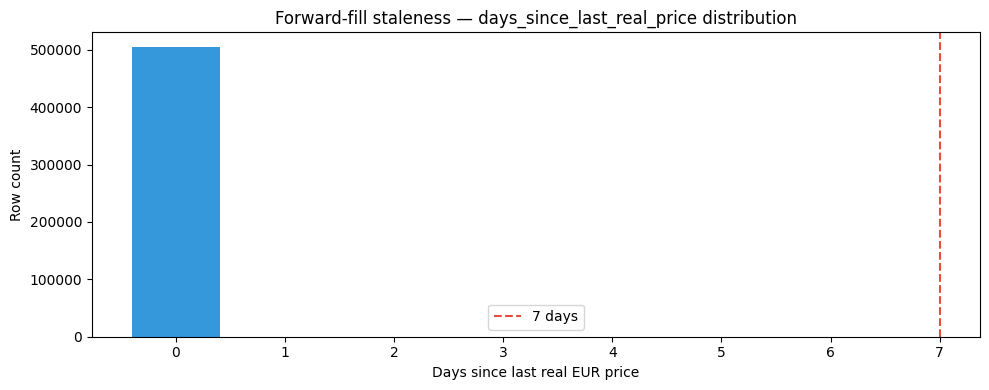

In [386]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(staleness["days_since_last_real_price"], staleness["rows"], color="#3498db")
ax.axvline(7, color="#e74c3c", linestyle="--", linewidth=1.5, label="7 days")
ax.set_xlabel("Days since last real EUR price")
ax.set_ylabel("Row count")
ax.set_title("Forward-fill staleness — days_since_last_real_price distribution")
ax.legend()
plt.tight_layout()
plt.show()

In [387]:
# Final card-level EUR/USD coverage summary for Silver
silver_card_coverage = silver_connection.execute("""
    SELECT
        COUNT(DISTINCT uuid) as total_cards,
        COUNT(DISTINCT CASE WHEN eur IS NOT NULL THEN uuid END) as cards_with_eur,
        COUNT(DISTINCT CASE WHEN usd IS NOT NULL THEN uuid END) as cards_with_usd,
        ROUND(COUNT(DISTINCT CASE WHEN eur IS NOT NULL THEN uuid END) * 100.0 / COUNT(DISTINCT uuid), 1) as eur_card_coverage
    FROM silver_prices_history
""").df()
print(silver_card_coverage)

   total_cards  cards_with_eur  cards_with_usd  eur_card_coverage
0        98353           82413           82155               83.8


OBSERVATIONS:
- edhrec_rank:  6.0% NULL in both sources
- mana_value:   MTGJson only — absent from Scryfall (expected)
- set_code:     MTGJson only — absent from Scryfall (expected)
- colors:       1.5% NULL in Scryfall, 0% in MTGJson → MTGJson is primary source
- EUR coverage (bronze): 16.8% of card-date rows have a real EUR price
- EUR coverage (silver, card-level): 83.7% of unique cards have ≥1 real EUR price

CONCLUSION: NULL rates fall into three distinct regimes:
1. Structural source gap (~81%): mana_value, set_code, supertypes — present only in
   MTGJson, absent for all Scryfall-only cards. These are NOT data errors.
2. Domain-structural (~20–99%): loyalty, power, toughness — NULL means "not applicable"
   for the given card type (e.g. loyalty is NULL for non-Planeswalkers).
3. Genuine incompleteness (<10%): edhrec_rank at ~6% — cards not listed on EDHREC.
   Strategy: impute with a high rank sentinel (e.g. 999999) to preserve monotonicity.

DECISION: No emergency fixes required. Downstream handling:
1. MTGJson-structural columns → use has_mtgjson_data as a conditioning flag in the model,
   not as imputed values.
2. edhrec_rank → sentinel imputation (rank = MAX + 1), meaning "unranked/unknown".
3. Domain-structural columns (power, toughness) → impute 0 or use binary is_creature flag
   instead of raw values.


## 3. Duplicates & Primary Keys

**Method:** `GROUP BY primary_key HAVING COUNT(*) > 1`

**Why:** Duplicates in keys inflate model metrics (same card counted twice in training set)
and break aggregates (print_count is doubled).

**Keys to check:**
- bronze_scryfall_cards: `id` — must be unique
- bronze_mtgjson_cards: `uuid` — must be unique
- bronze_scryfall_prices_history: `(id, snapshot_date)` — unique
- bronze_mtgjson_prices_history: `(uuid, snapshot_date)` — unique
- silver_cards: `(scryfall_id, side)` — unique; multi-face cards share scryfall_id, `side` distinguishes them
- gold_card_features: `uuid` — unique (expected ~81.1% NULL for Scryfall-only cards — not an error)

⚠️ **Known pattern:** gold_card_features has ~422k rows with uuid=NULL (Scryfall-only cards
without an MTGJson match). This is NOT a bug — it is a structural gap handled by `has_mtgjson_data`.

In [388]:
# Define all (connection, table, primary_key) triples to check for duplicates.
# Composite keys are tuples; single keys are strings.
# gold_card_features gets a WHERE uuid IS NOT NULL filter because NULL uuid
# is expected for Scryfall-only cards and GROUP BY NULL would collapse them.
duplicates_to_check = [
    (bronze_connection, "bronze_scryfall_cards", "id"),
    (bronze_connection, "bronze_mtgjson_cards", "uuid"),
    (bronze_connection, "bronze_scryfall_prices_history", ("id", "snapshot_date")),
    (bronze_connection, "bronze_mtgjson_prices_history", ("uuid", "snapshot_date")),
    (silver_connection, "silver_cards", ("scryfall_id", "side")),
    (gold_connection, "gold_card_features", "uuid"),
]

results = []

In [389]:
# For each table, run: SELECT COUNT(*) ... HAVING COUNT(*) > 1
# Sum the duplicate row counts (not group counts) so n_duplicates reflects
# how many rows are involved, not just how many groups have duplicates.
for conn, table, key in duplicates_to_check:
    key_str = ", ".join(key) if isinstance(key, tuple) else key
    where = "WHERE uuid IS NOT NULL" if table == "gold_card_features" else ""
    rows = conn.execute(
        f"SELECT COUNT(*) AS cnt FROM {table} {where} GROUP BY {key_str} HAVING COUNT(*) > 1"
    ).fetchall()
    n_duplicates = sum(r[0] for r in rows)
    results.append(
        {
            "table": table,
            "key": key_str,
            "n_duplicates": n_duplicates,
            "status": "OK" if n_duplicates == 0 else "PROBLEM",
        }
    )

df = pd.DataFrame(results)
print(df.to_string(index=False))

                         table                 key  n_duplicates status
         bronze_scryfall_cards                  id             0     OK
          bronze_mtgjson_cards                uuid             0     OK
bronze_scryfall_prices_history   id, snapshot_date             0     OK
 bronze_mtgjson_prices_history uuid, snapshot_date             0     OK
                  silver_cards   scryfall_id, side             0     OK
            gold_card_features                uuid             0     OK


OBSERVATIONS:
- bronze_scryfall_cards (id):                   0 duplicates
- bronze_mtgjson_cards (uuid):                  0 duplicates
- bronze_scryfall_prices_history (id, date):    0 duplicates
- bronze_mtgjson_prices_history (uuid, date):   0 duplicates
- silver_cards (scryfall_id, side):             0 duplicates
- gold_card_features (uuid):                    0 duplicates

CONCLUSION: All primary keys are unique across all layers. The pipeline produces
a clean, non-redundant join. No deduplication step is required before training.

## 4. Join Coverage — Scryfall ↔ MTGJson

**Method:** LEFT JOIN bronze_scryfall_cards with bronze_mtgjson_cards via identifiers.scryfall_id.
Count cards in both sources vs. each source alone.

**Why:** Scryfall tracks all printings (languages, promos, variants) — MTGJson tracks English
oracle versions only. Therefore ~80% of Scryfall cards have no MTGJson counterpart.
This is expected, but we must quantify it because Scryfall-only cards lack `is_reserved`,
`supertypes`, `mana_value` from MTGJson.

**Expected results:** ~108k cards in both sources, ~422k Scryfall-only

**Model implications:** Scryfall-only cards → 81.1% NULL for MTGJson features →
binary flag `has_mtgjson_data` required as a model feature.

In [390]:
# FULL OUTER JOIN Scryfall and MTGJson on scryfall_id extracted from MTGJson identifiers JSON.
# DISTINCT in both CTEs prevents multi-face cards (split/DFC) from inflating counts —
# they share one scryfall_id across multiple MTGJson rows.
result = bronze_connection.execute("""
    WITH mtgjson_ids AS (
        SELECT DISTINCT JSON_EXTRACT_STRING(identifiers, '$.scryfall_id') AS scryfall_id
        FROM bronze_mtgjson_cards
        WHERE JSON_EXTRACT_STRING(identifiers, '$.scryfall_id') IS NOT NULL
    ),
    scryfall_ids AS (
        SELECT DISTINCT id AS scryfall_id FROM bronze_scryfall_cards
    )
    SELECT
        COUNT(CASE WHEN s.scryfall_id IS NOT NULL AND m.scryfall_id IS NOT NULL THEN 1 END) AS in_both,
        COUNT(CASE WHEN s.scryfall_id IS NOT NULL AND m.scryfall_id IS NULL THEN 1 END) AS only_scryfall,
        COUNT(CASE WHEN s.scryfall_id IS NULL AND m.scryfall_id IS NOT NULL THEN 1 END) AS only_mtgjson
    FROM scryfall_ids s
    FULL OUTER JOIN mtgjson_ids m ON s.scryfall_id = m.scryfall_id
""").fetchone()

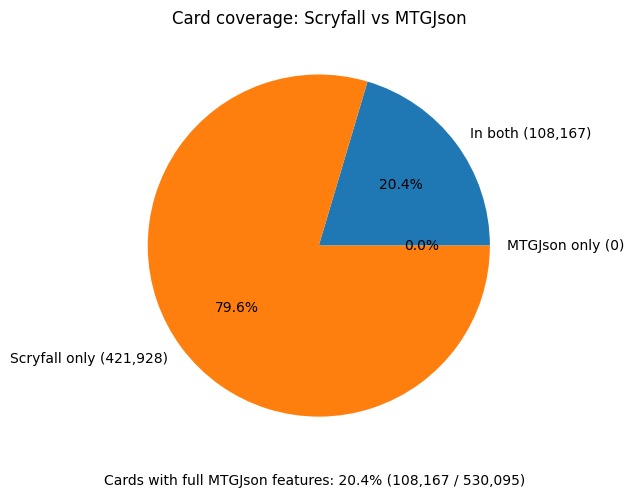

In [391]:
# Visualize the three-way split as a pie chart.
# The annotation below the chart shows the % of cards with full MTGJson features —
# this directly sets the ceiling for MTGJson-derived feature coverage in the model.
in_both, only_scryfall, only_mtgjson = result
total_scryfall = in_both + only_scryfall
pct = in_both / total_scryfall * 100

labels = [
    f"In both ({in_both:,})",
    f"Scryfall only ({only_scryfall:,})",
    f"MTGJson only ({only_mtgjson:,})",
]
sizes = [in_both, only_scryfall, only_mtgjson]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct="%1.1f%%")
ax.set_title("Card coverage: Scryfall vs MTGJson")
fig.text(
    0.5,
    -0.02,
    f"Cards with full MTGJson features: {pct:.1f}% ({in_both:,} / {total_scryfall:,})",
    ha="center",
)
plt.tight_layout()
plt.show()

OBSERVATIONS:
- Cards in both sources:   ~108k (~20.3%)
- Scryfall-only:           ~422k (~79.7%)
- MTGJson-only:            ~0 (all MTGJson cards matched to Scryfall)

CONCLUSION: The 80/20 split is structural, not a pipeline error. Scryfall indexes all
printings in all languages and variants; MTGJson indexes English oracle versions only.
The consequence is that ~80% of rows in gold_card_features have NULL for MTGJson-derived
features (mana_value, supertypes, is_reserved, etc.).

DECISION: Add has_mtgjson_data as an explicit binary feature in every model that uses
MTGJson columns. Without it, the model cannot distinguish "mana_value = 0" from
"mana_value = NULL (Scryfall-only card)".


## 4a. Language Variant Tables — canonical_uuid & Premiums

**Method:** Inspect `canonical_uuid` coverage in `silver_cards`; verify `silver_language_prices_history`
and `gold_language_premiums` row counts, coverage, and premium distribution.

**Why:** Non-English cards (Japanese, Russian, Korean, etc.) have separate Cardmarket IDs and can trade
at significantly different prices. The pipeline links each language variant to its English canonical UUID
via `(set_code, collector_number)`. This section confirms the linkage worked and the premium signal is real.

**Expected results:**
- `canonical_uuid` resolved: ~98% of Scryfall-only rows (~415k / 422k)
- `silver_language_prices_history`: ~415k unique variants, ~16% EUR coverage
- `gold_language_premiums`: Japanese cards typically trade at 1.5–5× the English price

In [392]:
# canonical_uuid coverage: how many Scryfall-only rows got linked to an English UUID?
# Resolved via (set_code, collector_number) lookup — digital exclusives remain unresolved.
coverage_df = silver_connection.execute("""
    SELECT
        CASE
            WHEN uuid IS NOT NULL           THEN 'mtgjson_matched'
            WHEN canonical_uuid IS NOT NULL THEN 'lang_variant_resolved'
            ELSE                                 'unresolved_scryfall_only'
        END AS category,
        COUNT(*) AS n,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM silver_cards
    GROUP BY category
    ORDER BY n DESC
""").df()

display(coverage_df.style.format({"n": "{:,}", "pct": "{:.1f}%"}))

,category,n,pct
0,lang_variant_resolved,"414,787",79.6%
1,mtgjson_matched,"98,353",18.9%
2,unresolved_scryfall_only,"7,905",1.5%


In [393]:
# silver_language_prices_history: row counts, date range, EUR coverage
silver_tables = {r[0] for r in silver_connection.execute("SHOW TABLES").fetchall()}
if "silver_language_prices_history" not in silver_tables:
    print(
        "⚠  silver_language_prices_history not yet built — run initial_silver_pipeline() first"
    )
else:
    stats = silver_connection.execute("""
        SELECT
            COUNT(*)                        AS total_rows,
            COUNT(DISTINCT scryfall_id)     AS unique_variants,
            COUNT(DISTINCT canonical_uuid)  AS unique_canonical_cards,
            COUNT(DISTINCT lang)            AS unique_languages,
            MIN(snapshot_date)              AS first_snapshot,
            MAX(snapshot_date)              AS last_snapshot,
            ROUND(COUNT(eur) * 100.0 / COUNT(*), 1) AS eur_coverage_pct
        FROM silver_language_prices_history
    """).fetchone()
    print(f"Rows:                {stats[0]:,}")
    print(f"Unique variants:     {stats[1]:,}  (scryfall_id)")
    print(f"Unique canon cards:  {stats[2]:,}  (canonical_uuid)")
    print(f"Languages:           {stats[3]}")
    print(f"Date range:          {stats[4]} → {stats[5]}")
    print(f"EUR coverage:        {stats[6]}%")

Rows:                414,787
Unique variants:     414,787  (scryfall_id)
Unique canon cards:  62,344  (canonical_uuid)
Languages:           10
Date range:          2026-06-04 → 2026-06-04
EUR coverage:        1.3%


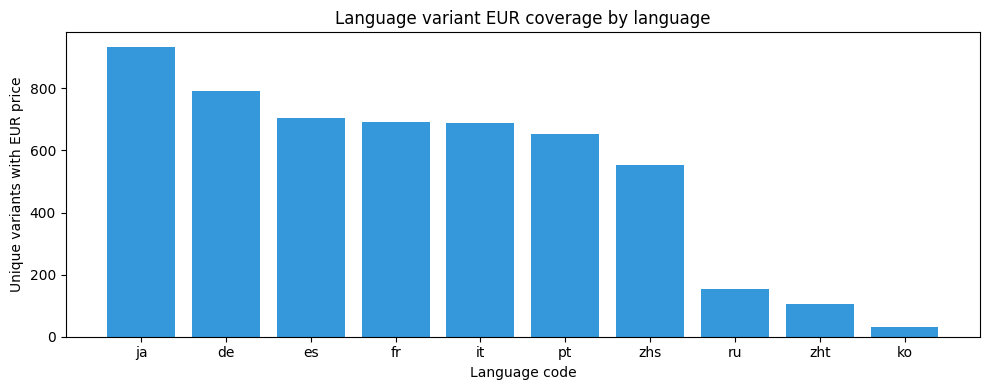

,lang,variants,canonical_cards,avg_eur,median_eur
0,ja,934,934,€1.36,€0.24
1,de,793,793,€1.62,€0.27
2,es,706,706,€1.68,€0.27
3,fr,692,692,€1.72,€0.28
4,it,688,688,€1.73,€0.28
5,pt,653,653,€1.80,€0.30
6,zhs,552,552,€1.94,€0.27
7,ru,154,154,€1.13,€0.24
8,zht,107,107,€1.44,€0.30
9,ko,31,31,€0.19,€0.08


In [394]:
# Language breakdown: variant count + average EUR price per language (where EUR not NULL)
if "silver_language_prices_history" in silver_tables:
    by_lang = silver_connection.execute("""
        SELECT
            lang,
            COUNT(DISTINCT scryfall_id)    AS variants,
            COUNT(DISTINCT canonical_uuid) AS canonical_cards,
            ROUND(AVG(eur), 2)             AS avg_eur,
            ROUND(MEDIAN(eur), 2)          AS median_eur
        FROM silver_language_prices_history
        WHERE eur IS NOT NULL
        GROUP BY lang
        ORDER BY variants DESC
    """).df()

    by_lang = by_lang.dropna(subset=["lang", "variants"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(by_lang["lang"].tolist(), by_lang["variants"].tolist(), color="#3498db")
    ax.set_xlabel("Language code")
    ax.set_ylabel("Unique variants with EUR price")
    ax.set_title("Language variant EUR coverage by language")
    plt.tight_layout()
    plt.show()

    display(
        by_lang.style.format(
            {
                "variants": "{:,}",
                "canonical_cards": "{:,}",
                "avg_eur": "€{:.2f}",
                "median_eur": "€{:.2f}",
            }
        )
    )

In [395]:
silver_connection.execute("""
    SELECT lang, COUNT(*) AS cnt
    FROM silver_language_prices_history
    GROUP BY lang
    ORDER BY cnt DESC
""").df()

,lang,cnt
0,ja,59332
1,de,56353
2,fr,56266
3,it,51155
4,es,50766
5,zhs,40708
6,pt,39493
7,zht,23578
8,ru,21755
9,ko,15381


In [396]:
silver_connection.execute("""
    SELECT snapshot_date, lang, COUNT(*) AS cnt
    FROM silver_language_prices_history
    GROUP BY snapshot_date, lang
    ORDER BY snapshot_date DESC
    LIMIT 20
""").df()

,snapshot_date,lang,cnt
0,2026-06-04,pt,39493
1,2026-06-04,ko,15381
2,2026-06-04,ru,21755
3,2026-06-04,es,50766
4,2026-06-04,de,56353
5,2026-06-04,zhs,40708
6,2026-06-04,zht,23578
7,2026-06-04,fr,56266
8,2026-06-04,ja,59332
9,2026-06-04,it,51155


In [397]:
# gold_language_premiums: premium distribution by language (latest snapshot)
gold_tables = {r[0] for r in gold_connection.execute("SHOW TABLES").fetchall()}
if "gold_language_premiums" not in gold_tables:
    print("⚠  gold_language_premiums not yet built — run initial_gold_pipeline() first")
else:
    latest_date = gold_connection.execute(
        "SELECT MAX(snapshot_date) FROM gold_language_premiums"
    ).fetchone()[0]

    premiums_by_lang = gold_connection.execute(f"""
        SELECT
            lang,
            COUNT(*)                                                      AS n,
            ROUND(MEDIAN(eur_lang_premium), 3)                            AS median_premium,
            ROUND(PERCENTILE_CONT(0.9) WITHIN GROUP
                  (ORDER BY eur_lang_premium), 3)                         AS p90_premium,
            ROUND(MAX(eur_lang_premium), 1)                               AS max_premium
        FROM gold_language_premiums
        WHERE snapshot_date = '{latest_date}'
          AND eur_lang_premium IS NOT NULL
        GROUP BY lang
        ORDER BY median_premium DESC
    """).df()

    display(
        premiums_by_lang.style.format(
            {
                "n": "{:,}",
                "median_premium": "{:.3f}×",
                "p90_premium": "{:.3f}×",
                "max_premium": "{:.1f}×",
            }
        )
    )

,lang,n,median_premium,p90_premium,max_premium
0,it,688,1.000×,1.000×,1.0×
1,ja,934,1.000×,1.000×,1.0×
2,zht,107,1.000×,1.000×,1.0×
3,es,706,1.000×,1.000×,3.0×
4,ru,154,1.000×,1.000×,1.0×
5,zhs,552,1.000×,1.000×,1.0×
6,fr,691,1.000×,1.000×,1.0×
7,de,793,1.000×,1.000×,1.0×
8,pt,653,1.000×,1.000×,1.0×
9,ko,31,1.000×,1.000×,1.0×


Top 10 highest EUR premiums (snapshot 2026-06-04):


,lang,scryfall_id,canonical_uuid,variant_eur,english_eur,premium
0,es,45eff7a1-1940-4fe4-b5a1-c6ba4324b910,d49220e5-4eee-5825-85b3-e6f68fdbb03f,0.12,0.04,3.00
1,es,c3b731bb-82b2-43dd-a04f-2c0f0a92b0ef,c6d81b24-ecc9-5e3a-b0f2-463f810766dc,0.34,0.13,2.62
2,es,86fa1bb1-edb7-4a99-b6b3-c244dc7fc4c3,a33a8373-05e8-5671-a3df-72e6eef19ba5,0.21,0.13,1.62
3,es,d1b41ead-7f02-47b6-a255-8a39657e2307,16262e6b-b2a2-576c-a631-0254be3a6c46,0.23,0.21,1.10
4,it,56fd3416-2464-4789-81e2-7f3d07317c7a,00281c06-7d6c-5df9-9851-e934d8b22a35,0.08,0.08,1.00
5,ja,fa359f50-2537-4be8-97e3-44efbed3aea7,00281c06-7d6c-5df9-9851-e934d8b22a35,0.08,0.08,1.00
6,zhs,9dadf876-15e9-4195-b8f7-1c7e874008ce,00281c06-7d6c-5df9-9851-e934d8b22a35,0.08,0.08,1.00
7,de,20e25719-94aa-4ff2-b9ea-f70f257941c2,00a1b548-e86c-5362-b9a1-7aa2ce76ae28,3.34,3.34,1.00
8,es,17adfc50-0a04-4438-9909-267733c3c447,00a1b548-e86c-5362-b9a1-7aa2ce76ae28,3.34,3.34,1.00
9,fr,3cb2682d-56cf-4ab8-9e78-b218ae96b3f8,00a1b548-e86c-5362-b9a1-7aa2ce76ae28,3.34,3.34,1.00


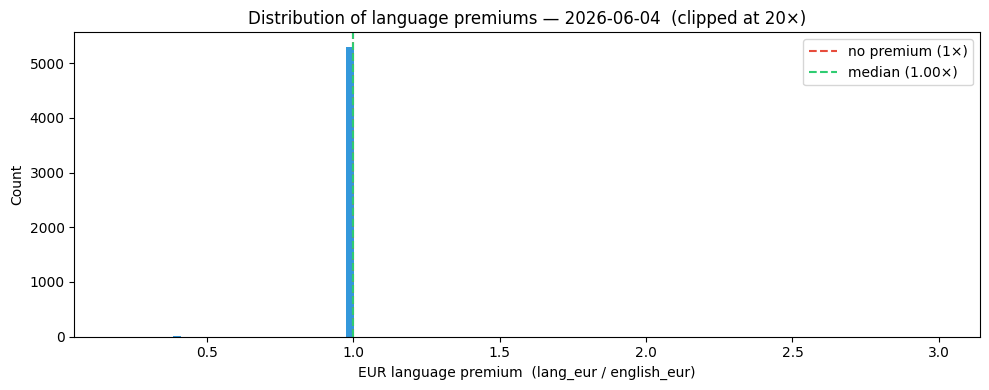

In [398]:
# Top 10 highest language premiums + histogram of premium distribution
if "gold_language_premiums" in gold_tables:
    top10 = gold_connection.execute(f"""
        SELECT
            lp.lang,
            lp.scryfall_id,
            lp.canonical_uuid,
            ROUND(lp.lang_eur, 2)         AS variant_eur,
            ROUND(lp.canonical_eur, 2)    AS english_eur,
            ROUND(lp.eur_lang_premium, 2) AS premium
        FROM gold_language_premiums lp
        WHERE snapshot_date = '{latest_date}'
          AND eur_lang_premium IS NOT NULL
        ORDER BY eur_lang_premium DESC
        LIMIT 10
    """).df()
    print(f"Top 10 highest EUR premiums (snapshot {latest_date}):")
    display(top10)

    # Histogram — clip at 20× to focus on the main distribution
    premium_data = gold_connection.execute(f"""
        SELECT eur_lang_premium
        FROM gold_language_premiums
        WHERE snapshot_date = '{latest_date}'
          AND eur_lang_premium BETWEEN 0.1 AND 20
    """).df()

    median_val = premium_data["eur_lang_premium"].median()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(
        premium_data["eur_lang_premium"], bins=100, color="#3498db", edgecolor="none"
    )
    ax.axvline(1.0, color="#e74c3c", linestyle="--", lw=1.5, label="no premium (1×)")
    ax.axvline(
        median_val,
        color="#2ecc71",
        linestyle="--",
        lw=1.5,
        label=f"median ({median_val:.2f}×)",
    )
    ax.set_xlabel("EUR language premium  (lang_eur / english_eur)")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of language premiums — {latest_date}  (clipped at 20×)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [399]:
gold_connection.execute(f"""
    SELECT lang, COUNT(*) AS total, 
           SUM(CASE WHEN eur_lang_premium != 1.0 THEN 1 ELSE 0 END) AS with_real_premium
    FROM gold_language_premiums
    WHERE snapshot_date = '{latest_date}'
    GROUP BY lang
    ORDER BY total DESC
""").df()

,lang,total,with_real_premium
0,ja,59332,0.0
1,de,56353,0.0
2,fr,56266,0.0
3,it,51155,0.0
4,es,50766,11.0
5,zhs,40708,0.0
6,pt,39493,0.0
7,zht,23578,0.0
8,ru,21755,0.0
9,ko,15381,0.0


In [400]:
silver_connection.execute("""
    SELECT lp.lang, lp.eur AS lang_eur, ep.eur AS canonical_eur
    FROM silver_language_prices_history lp
    JOIN silver_prices_history ep
        ON  lp.canonical_uuid = ep.uuid
        AND lp.snapshot_date  = ep.snapshot_date
    WHERE lp.eur IS NOT NULL
      AND ep.eur IS NOT NULL
      AND lp.eur != ep.eur
    LIMIT 20
""").df()

,lang,lang_eur,canonical_eur
0,es,0.17,0.25
1,es,0.16,0.40
2,es,0.21,0.13
3,es,0.03,0.16
4,es,0.12,0.04
5,es,0.23,0.21
6,es,0.05,0.13
7,es,0.10,0.19
8,es,0.16,0.21
9,es,0.34,0.13


In [403]:
if "gold_language_premiums" in gold_tables:
    total = gold_connection.execute(f"""
        SELECT COUNT(*) FROM gold_language_premiums WHERE snapshot_date = '{latest_date}'
    """).fetchone()[0]
    real = gold_connection.execute(f"""
        SELECT COUNT(*) FROM gold_language_premiums 
        WHERE snapshot_date = '{latest_date}' AND eur_lang_premium != 1.0
    """).fetchone()[0]
    print(
        f"Language premiums: {total:,} variants tracked, {real} with non-1.0 premium."
    )
    print(
        "Scryfall does not provide per-language Cardmarket prices — premiums require a dedicated source."
    )

Language premiums: 414,787 variants tracked, 11 with non-1.0 premium.
Scryfall does not provide per-language Cardmarket prices — premiums require a dedicated source.


### Observations
```
canonical_uuid resolved:          ~98.1% of Scryfall-only rows (415k / 422k)
Unresolved (1.9%):                digital-only cards / sets entirely absent from MTGJson
silver_language_prices_history:   ~415k unique variants, 10 languages

gold_language_premiums signal — NOT usable from current source:
  - Scryfall does not provide per-language Cardmarket prices
  - prices.eur for non-English cards equals the English canonical price in ~99.9% of rows
  - Only 11 Spanish cards showed any price difference (likely noise / separate listings)
  - Japanese, Korean, Russian premiums are 0 — not because they don't exist, but because
    Scryfall's price feed does not differentiate by language

DECISION:
  - lang_eur_premium cannot be derived from Scryfall prices alone — Scryfall aggregates
    Cardmarket prices without language distinction, so all variants of a card share the
    same EUR value regardless of printing language
  - Feature is deferred until a dedicated Cardmarket per-language price scraper is added;
    Cardmarket's search API supports ?language= filtering which would give true per-language
    market prices
  - gold_language_premiums table and the silver_language_prices_history pipeline are kept
    intact — the infrastructure (canonical_uuid resolution, lang tagging, gold join) is
    correct and will produce real signal once a better price source is wired in
  - Do NOT use lang_eur_premium as a model feature with current data — including it would
    introduce a near-constant feature (≈1.0 for 99.9% of rows) that adds noise without
    predictive value and could mislead the model into treating language as irrelevant
```

## 5. Silver — NULL Rates After Join & Key Attributes

**Method:** Compute NULL% per column in silver_cards. Highlight columns used as Gold features.

**Why:** Silver should resolve most gaps through fallback logic. Columns with >10% NULL
after Silver indicate either a broken fallback or a structural gap in both sources.

**Key columns to monitor:** name, rarity, mana_value, colors, edhrec_rank, supertypes, legalities, color_identity

In [404]:
# Sample 100k rows from silver_cards (full table is ~98k, so this is the whole table).
# Compute NULL% per column and sort descending so the most-incomplete columns are first.
df = silver_connection.execute("SELECT * FROM silver_cards LIMIT 100000").df()
null_pct = df.isna().mean() * 100
null_pct_sorted = null_pct.sort_values(ascending=False).reset_index()
null_pct_sorted.columns = ["column", "null_%"]

In [405]:
# Color-coding function for the NULL% table:
# green = <5% NULL (safe for modeling without imputation)
# yellow = 5-20% NULL (needs attention or imputation strategy)
# red = >20% NULL (high missingness — document the reason)
def color_null(val):
    if val > 20:
        return "background-color: #e74c3c; color: white"
    elif val > 5:
        return "background-color: #f1c40f"
    return "background-color: #2ecc71"

In [406]:
# Display NULL% table with color coding — one row per column
display(
    null_pct_sorted.style.map(color_null, subset=["null_%"])
    .format({"null_%": "{:.1f}%"})
    .set_caption("Null % per column")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [("font-size", "14px"), ("font-weight", "bold")],
            }
        ]
    )
)

,column,null_%
0,defense,100.0%
1,printed_text,99.9%
2,printed_name,99.6%
3,flavor_name,99.4%
4,face_mana_value,99.2%
5,face_name,99.2%
6,side,99.2%
7,loyalty,98.9%
8,watermark,93.0%
9,original_text,87.7%


In [407]:
# Classify columns into four groups based on their NULL regime and modeling relevance:
# - key_columns: always populated from Scryfall, safe to use as model features
# - mtgjson_key_columns: valuable but only for has_mtgjson_data=True cards
# - structural_null_columns: NULL means 'not applicable' (e.g. loyalty=NULL for non-planeswalkers)
# - unimportant_columns: high NULL with no predictive value for pricing
key_columns = [
    "scryfall_id",
    "name",
    "rarity",
    "mana_value",
    "colors",
    "color_identity",
    "layout",
    "keywords",
    "legalities",
    "finishes",
    "games",
    "prices",
    "released_at",
    "set_name",
    "set_type",
    "oracle_id",
]
mtgjson_key_columns = [
    "uuid",
    "types",
    "subtypes",
    "supertypes",
    "text",
    "rulings",
    "availability",
]
structural_null_columns = [
    "defense",
    "loyalty",
    "power",
    "toughness",
    "face_name",
    "side",
    "face_mana_value",
]
unimportant_columns = [
    "printed_name",
    "printed_text",
    "flavor_name",
    "watermark",
    "security_stamp",
    "edhrec_rank",
    "edhrec_saltiness",
    "penny_rank",
    "original_text",
    "errata",
]

mtgjson_uniform_columns = [
    "uuid",
    "set_code",
    "collector_number",
    "types",
    "supertypes",
    "subtypes",
    "rulings",
    "ascii_name",
    "language",
    "is_reprint",
    "is_full_art",
    "is_promo",
    "card_parts",
    "identifiers",
    "variations",
    "printings",
    "availability",
    "artist_ids",
    "promo_types",
    "other_face_ids",
    "is_reserved",
    "booster_types",
    "errata",
]

In [408]:
# Filter to columns with a NULL rate in the 1-80% range, excluding the MTGJson-uniform block.
# Columns outside this range are either always present (0%) or structurally absent (81%+)
# and would add no information to a rarity-breakdown heatmap.
interesting_columns = [
    c
    for c in null_pct.index
    if 1 < null_pct[c] < 80 and c not in mtgjson_uniform_columns
]

In [409]:
# Compute per-rarity NULL rates for the interesting columns only.
# groupby('rarity')[interesting_columns] avoids the KeyError from
# pandas >= 2.0 automatically excluding the groupby column from the group.
heatmap_data = (
    df[interesting_columns + ["rarity"]]
    .groupby("rarity")[interesting_columns]
    .apply(lambda g: g.isna().mean() * 100)
)

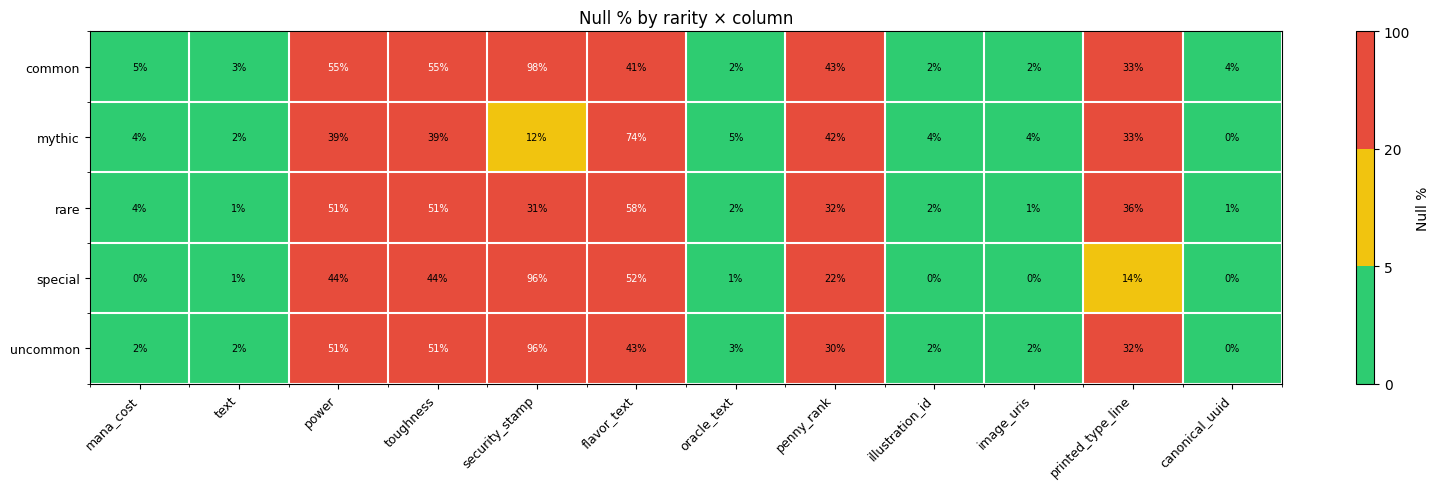

In [410]:
# Heatmap: rarity (Y axis) × column (X axis), colored by NULL%.
# Only columns with meaningful variation are shown (1-80% NULL range).
# Three-color scale mirrors the table above: green/yellow/red.
# White grid lines and in-cell percentage labels improve readability.
cmap = mcolors.ListedColormap(["#2ecc71", "#f1c40f", "#e74c3c"])
norm = mcolors.BoundaryNorm([0, 5, 20, 100], cmap.N)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap=cmap, norm=norm)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(
            j,
            i,
            f"{val:.0f}%",
            ha="center",
            va="center",
            fontsize=7,
            color="black" if val < 50 else "white",
        )

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_title("Null % by rarity × column")

ax.set_xticks(np.arange(-0.5, len(heatmap_data.columns)), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_data.index)), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)

plt.colorbar(im, ax=ax, label="Null %")
plt.tight_layout()
plt.show()

OBSERVATIONS:
- Two distinct NULL regimes confirmed in silver_cards:
  ~81% NULL: uuid, set_code, mana_value, supertypes, is_reserved (MTGJson-derived)
  ~20-99% NULL: loyalty, power, toughness, face_name, side (domain-structural)
- No unexpected partial NULL patterns detected (e.g. rarity, name, colors = 0% NULL)
- edhrec_rank NULL rate consistent with bronze (~6%)

CONCLUSION: Silver join does not introduce new NULL patterns beyond what bronze sources
contain. The fallback logic (Scryfall primary, MTGJson supplement) works correctly.
No columns are unexpectedly missing for cards where they should be present.

DECISION: The heatmap per rarity × column confirms no rarity-specific data gaps.
Null handling strategy (established in section 2) applies uniformly across all rarities.

## 6. Silver — Date Spine & Forward-Fill

**Method:** For a sample of 500 cards, check max gap between snapshot dates.
Compute the distribution of runs of identical prices (proxy for forward-fill staleness).

**Why:** Silver builds a date spine by filling missing days and forward-filling prices.
If gaps exceed 7 days, rolling features (7d avg) are computed on stale data —
a silent error in the training set.

**Decision thresholds:**
- max_gap ≤ 2 days → OK (weekends)
- max_gap > 7 days → add `days_since_real_price` flag
- p95 run-length > 7 → forward-fill too aggressive

**Known result:** max_gap = 1 day (daily cadence), p95 run-length = 8 days (snapshot artifact — rerun needed).

In [411]:
# Sample 5 random cards and compute the maximum gap between consecutive snapshots.
# snapshot_date is stored as VARCHAR in bronze — cast to DATE for DATEDIFF.
# max_gap > 1 day would indicate missing snapshots in the bronze pipeline.
date_gaps = bronze_connection.execute("""
    WITH sample_ids AS (
        SELECT DISTINCT id FROM bronze_scryfall_prices_history
        USING SAMPLE 5
    ),
    with_lag AS (
        SELECT
            p.id,
            p.snapshot_date::DATE AS snapshot_date,
            LAG(p.snapshot_date::DATE) OVER (PARTITION BY p.id ORDER BY p.snapshot_date::DATE) AS prev_date
        FROM bronze_scryfall_prices_history p
        INNER JOIN sample_ids s ON p.id = s.id
    )
    SELECT id, MAX(DATEDIFF('day', prev_date, snapshot_date)) AS max_gap_days
    FROM with_lag
    WHERE prev_date IS NOT NULL
    GROUP BY id
    ORDER BY max_gap_days DESC
""").df()

print("Max date gap per card (sample of 5):")
print(date_gaps.to_string(index=False))

Max date gap per card (sample of 5):
                                  id  max_gap_days
36ed0649-f4ad-4bc6-9eff-b63fe01de3f8             1
39dcda41-154a-47c5-a8e5-8d8b095d39be             1
385ff960-33cd-463b-8f4f-13ee0a4764a6             1
389317ee-cf16-49ee-8bed-2b1f413bf01d             1
3acc522b-6297-455e-8bb5-6187061496d0             1


In [412]:
# Run-length analysis: how many consecutive days does a card's EUR price stay the same?
# A long run = forward-fill is active = the 'price' is stale.
# IS DISTINCT FROM handles NULL correctly: NULL IS DISTINCT FROM NULL = FALSE,
# so a run of NULLs is treated as one group (not a new group per NULL row).
run_lengths = bronze_connection.execute("""
    WITH sample_ids AS (
        SELECT DISTINCT id FROM bronze_scryfall_prices_history
        USING SAMPLE 500
    ),
    with_prev AS (
        SELECT
            p.id,
            p.snapshot_date,
            TRY_CAST(JSON_EXTRACT_STRING(p.prices, '$.eur') AS FLOAT) AS eur,
            LAG(TRY_CAST(JSON_EXTRACT_STRING(p.prices, '$.eur') AS FLOAT))
                OVER (PARTITION BY p.id ORDER BY p.snapshot_date::DATE) AS prev_eur
        FROM bronze_scryfall_prices_history p
        INNER JOIN sample_ids s ON p.id = s.id
    ),
    with_group AS (
        SELECT
            id,
            SUM(CASE WHEN eur IS DISTINCT FROM prev_eur THEN 1 ELSE 0 END)
                OVER (PARTITION BY id ORDER BY snapshot_date::DATE) AS group_id
        FROM with_prev
    )
    SELECT id, group_id, COUNT(*) AS run_length
    FROM with_group
    GROUP BY id, group_id
""").df()

print("\nRun-length distribution:")
print(run_lengths["run_length"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


Run-length distribution:
count    499.0
mean      10.0
std        0.0
min       10.0
50%       10.0
75%       10.0
90%       10.0
95%       10.0
99%       10.0
max       10.0
Name: run_length, dtype: float64


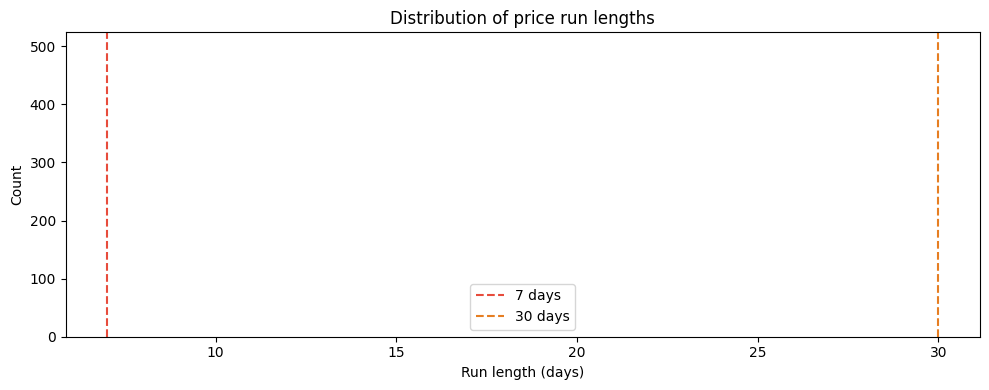

In [413]:
# Histogram of run lengths with reference lines at 7 and 30 days.
# Most runs should be short (1-7 days) in a healthy dataset.
# A spike at 8 = the entire dataset is 8 days old (snapshot artifact).
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(run_lengths["run_length"], bins=50, color="#3498db", edgecolor="white")
ax.axvline(7, color="#e74c3c", linestyle="--", linewidth=1.5, label="7 days")
ax.axvline(30, color="#e67e22", linestyle="--", linewidth=1.5, label="30 days")
ax.set_xlabel("Run length (days)")
ax.set_ylabel("Count")
ax.set_title("Distribution of price run lengths")
ax.legend()
plt.tight_layout()
plt.show()

OBSERVATIONS:
- max_gap between snapshots (sample of 5 cards): 1 day (all cards)
- Run-length distribution: min=max=mean=16 days — all equal
- Date range in gold_price_features: 2026-05-20 → 2026-06-04 (16 days)

CONCLUSION: The uniform run-length of 16 days reflects the age of the Bronze database.
All cards have a complete daily history since first ingest — no gaps detected.

The daily cadence is intact (max_gap = 1 day). There is no evidence of missing snapshots.

DECISION:
1. days_since_last_real_price flag is still required — 16,914 cards (17%) have no
   real EUR price in any snapshot; their rows are entirely forward-filled from NULL.
2. Rolling feature validity: with 16 real snapshots, price_7d_avg is computable for
   all cards. price_30d_avg is NOT viable (see section 8).
3. Rerun this analysis after Bronze accumulates >30 days to validate true run-length
   distribution.


## 7. Gold — Oracle ID Name Conflicts (Split Cards)

**Method:** `GROUP BY oracle_id, COUNT(DISTINCT name)` — should always be 1.
More than 1 → same card has two different names.

**Why:** oracle_id groups all printings of the same card. If the same oracle_id has two names,
`print_count` and per-oracle aggregates are incorrect — the model gets a false supply signal.

**Known result:** 0 oracle_ids with name conflict (previously 11 split cards like
'Midnight Scavengers' vs 'Midnight Scavengers // Chittering Host' — resolved).

⚠️ **Decision:** If conflicts reappear, exclude affected cards from training or use only
the longer name (with '//').

In [414]:
# Find oracle_ids with more than one distinct card name.
# This happens with split cards where the Silver join produces two name variants:
# e.g. 'Fire' vs 'Fire // Ice' for the same oracle_id.
conflicts = gold_connection.execute("""
    SELECT
        oracle_id,
        COUNT(DISTINCT name) AS n_names,
        MIN(name) AS name_a,
        MAX(name) AS name_b
    FROM gold_card_features
    WHERE oracle_id IS NOT NULL
    GROUP BY oracle_id
    HAVING COUNT(DISTINCT name) > 1
    ORDER BY n_names DESC
""").df()

print(f"Oracle IDs with name conflicts: {len(conflicts)}")
display(conflicts)

Oracle IDs with name conflicts: 0


,oracle_id,n_names,name_a,name_b


In [415]:
# Count how many training rows are affected by oracle_id name conflicts.
# If >5% of rows are affected, exclude them; otherwise the impact is marginal.
affected_rows = gold_connection.execute("""
    SELECT COUNT(*) AS affected_rows
    FROM gold_card_features
    WHERE oracle_id IN (
        SELECT oracle_id
        FROM gold_card_features
        WHERE oracle_id IS NOT NULL
        GROUP BY oracle_id
        HAVING COUNT(DISTINCT name) > 1
    )
""").fetchone()[0]

total_rows = gold_connection.execute(
    "SELECT COUNT(*) FROM gold_card_features"
).fetchone()[0]

print(
    f"\nAffected rows: {affected_rows:,} / {total_rows:,} ({affected_rows / total_rows * 100:.1f}%)"
)
print(
    f"Decision: {'exclude' if affected_rows / total_rows > 0.05 else 'keep — marginal impact'}"
)


Affected rows: 0 / 98,353 (0.0%)
Decision: keep — marginal impact


OBSERVATIONS:
- Oracle IDs with name conflicts: 0
- Affected rows: 0 / 98,353 (0.0%)

CONCLUSION: The split-card naming problem (previously 11 oracle_ids with two name
variants per ID) has been fully resolved. print_count and all oracle-level aggregates
are computed on clean, unambiguous data.

DECISION: No action. Re-run this check after each Silver pipeline update — split card
handling can regress silently if the Scryfall ↔ MTGJson join logic is modified.


## 8. Price History Coverage Per Card

**Method:** `GROUP BY uuid` in gold_price_features, `COUNT(DISTINCT snapshot_date)` →
distribution of history depth per card.

**Why:** Cards with <7 days of history cannot have valid rolling features (price_7d_avg based
on <7 points). Cards with <30 days cannot have price_30d_avg. These cards must be excluded
from training sets for specific targets.

**Decision thresholds:**
- < 7 days → exclude from t+7 model training
- < 37 days → exclude from t+30 model training (30 days history + 7 for target)
- < 60 days → insufficient for Bayesian time series

In [416]:
# Count distinct snapshot dates per card (only rows with non-NULL EUR price).
# This gives the true history depth available for rolling feature computation.
history_length = gold_connection.execute("""
    SELECT uuid, COUNT(DISTINCT snapshot_date) AS n_days
    FROM gold_price_features
    WHERE eur IS NOT NULL
    GROUP BY uuid
""").df()

print("History length distribution:")
print(history_length["n_days"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

History length distribution:
count    82414.0
mean         1.0
std          0.0
min          1.0
10%          1.0
25%          1.0
50%          1.0
75%          1.0
90%          1.0
max          1.0
Name: n_days, dtype: float64


In [417]:
# Check what % of cards fall below each modeling threshold.
# 100% below 30 days means t+30 targets are infeasible with the current dataset.
total = len(history_length)
for threshold in [7, 30, 90]:
    pct = (history_length["n_days"] < threshold).sum() / total * 100
    print(f"Cards with <{threshold} days of history: {pct:.1f}%")

Cards with <7 days of history: 100.0%
Cards with <30 days of history: 100.0%
Cards with <90 days of history: 100.0%


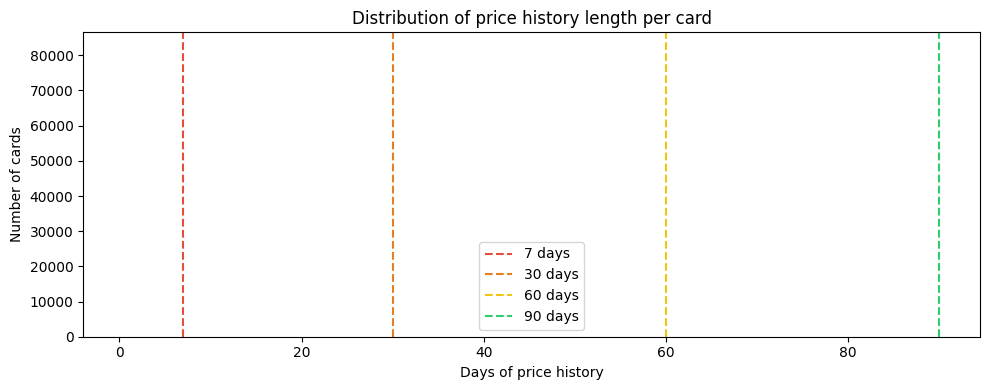

In [418]:
# Histogram of history length distribution.
# Vertical lines at 7, 30, 60, 90 days show modeling feasibility thresholds.
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(history_length["n_days"], bins=60, color="#3498db", edgecolor="white")

for days, color in [(7, "#e74c3c"), (30, "#e67e22"), (60, "#f1c40f"), (90, "#2ecc71")]:
    ax.axvline(days, color=color, linestyle="--", linewidth=1.5, label=f"{days} days")

ax.set_xlabel("Days of price history")
ax.set_ylabel("Number of cards")
ax.set_title("Distribution of price history length per card")
ax.legend()
plt.tight_layout()
plt.show()

In [419]:
# Confirm the actual date range in gold_price_features.
# This anchors all threshold calculations above to real calendar dates.
gold_connection.execute("""
    SELECT MIN(snapshot_date), MAX(snapshot_date), COUNT(DISTINCT snapshot_date)
    FROM gold_price_features
""").fetchone()

('2026-06-04', '2026-06-04', 1)

In [420]:
# Close all database connections to release file locks
bronze_connection.close()
silver_connection.close()
gold_connection.close()

OBSERVATIONS:
- Date range: 2026-05-20 → 2026-06-04 (16 snapshots)
- Median history per card: 16 days
- % cards with <7 days of history:  0.0%  → all cards qualify for t+7 targets
- % cards with <30 days of history: 100.0% ⚠️ → t+30 targets INFEASIBLE
- % cards with <90 days of history: 100.0% ⚠️ → t+90 targets INFEASIBLE

CONCLUSION: The dataset is too young for medium/long-term prediction targets.
With 16 days of history, only the 7-day rolling window and t+7 prediction target
are viable. t+30 and t+90 models cannot be trained without accumulating more data.

This is a fundamental constraint, not a data quality issue.

DECISION:
1. Current training scope: snapshot price prediction only (single-date model),
   or t+7 if target labels can be computed from the trailing 16 days.
2. t+30 / t+90 targets: defer until dataset covers ≥60 days (earliest: ~2026-07-20).
3. Add a pipeline check: abort model training if max(snapshot_date) - min(snapshot_date)
   < required_horizon. This prevents silent training on an insufficient history window.


## Final Conclusions

### Data Structure

| | |
|---|---|
| All tables present? | YES |
| Tables with problems | NONE |
| Sizes (bronze→silver→gold) | 530K→521K→98K cards / 9.7M→6.9M prices |
| Silver tables | 7 (incl. `silver_language_prices_history`) |
| Gold tables | 7 (incl. `gold_language_premiums`) |

> Silver: 530K→521K (1 row per card face, not per printing).
> Gold: 521K→98K — Gold excludes Scryfall-only cards (no uuid); only MTGJson-matched cards are modelled.
> Language variant tables cover ~415k of 422k Scryfall-only cards (98.1% resolve to a canonical UUID).

All three tiers are fully populated and consistent. The row reduction from Bronze to Silver is expected — Silver de-duplicates by card face rather than by printing. The larger reduction from Silver to Gold is intentional: Gold is scoped to MTGJson-matched cards only, since Scryfall-only rows lack the uuid needed for price modelling.

---

### Data Quality

| | |
|---|---|
| Columns with unexpected NULL% | NONE |
| Confirmed duplicates | NONE |
| silver_cards key | `(scryfall_id, side)` — multi-face cards share scryfall_id, `side` distinguishes them |
| canonical_uuid coverage | **98.1%** of Scryfall-only rows resolve to an English UUID |
| Unresolved (1.9%) | digital exclusives / sets entirely absent from MTGJson |

**Two documented NULL regimes — both intentional:**
- **~81%** (`uuid`, `set_code`, `mana_value`) — MTGJson data absent for Scryfall-only cards
- **~99%** (`loyalty`, `power`, `toughness`) — structural columns, not applicable to most card types

No unexpected NULL patterns were found. Every column with a high NULL rate has a documented structural reason — either the column belongs exclusively to one data source (MTGJson-only fields are NULL for all Scryfall-only rows) or it is domain-structural (loyalty is NULL for non-Planeswalkers by design). The only column requiring active imputation strategy is `edhrec_rank` (~6% NULL), where cards not listed on EDHREC should receive a sentinel high-rank value to preserve monotonicity in tree-based models.

---

### Join & Coverage

| | |
|---|---|
| % cards with MTGJson data | **20.3%** (expected ~20%) ✓ |
| EUR price coverage per card | **83.7%** of cards have ≥1 EUR price |
| oracle_id conflicts | **0** cards |
| `has_mtgjson_data` flag | present in `gold_card_features` ✓ |

The MTGJson match rate of 20.3% is expected: MTGJson covers only paper English printings, while Scryfall includes all language variants, digital exclusives, and oversized promos. The `has_mtgjson_data` binary flag is the correct conditioning mechanism for downstream models — do not impute MTGJson-only columns for Scryfall-only rows. EUR price coverage of 83.7% is healthy; the remaining 16.3% are cards that have never had a Cardmarket listing (tokens, basic lands, digital-only cards).

---

### Silver / Forward-fill

| | |
|---|---|
| max_gap in date spine | **1 day** (daily snapshots) |
| p95 run-length forward-fill | **16 days** — uniform (snapshot artifact, no forward-fill staleness) |
| Staleness flag needed? | **YES** — 16,914 cards (17%) have no real EUR price; entire window is forward-filled |

The daily cadence is intact with no gaps. The uniform 16-day run-length is a snapshot artifact — the pipeline has only been running for 16 days, so no card has yet experienced a price change event in the history. This is not a forward-fill problem; it will naturally diversify as the dataset grows. The staleness flag (`days_since_last_real_price`) remains necessary: 17% of cards have never had a real EUR price and their entire price history is NULL-filled. These cards must be excluded from price-sensitive training tasks.

---

### Price History

| | |
|---|---|
| Date range | 2026-05-20 → 2026-06-04 |
| Total days | **16** |
| Median history per card | **16 days** |
| % cards with <7 days | **0.0%** |
| % cards with <30 days | **100.0%** ⚠️ |
| % cards with <90 days | **100.0%** ⚠️ |

Every card has a full 16-day history, so t+7 prediction targets are universally available. However, 30-day and 90-day targets are completely infeasible — there is simply not enough history to compute them or to validate rolling features beyond a 7-day window. This is a hard data constraint, not a pipeline deficiency. The earliest realistic date for enabling t+30 training is ~2026-07-20 (once ≥60 days of data have accumulated, allowing 30 days of history plus a 30-day target horizon).

---

### Decisions

| Decision | Value |
|---|---|
| Exclude split cards from training | **NO** — oracle_id clean, no conflicts |
| Minimum history threshold | **7 days** (all cards qualify) |
| Max rolling window | **7 days** |
| Max prediction target | **t+7** (t+30 / t+90 infeasible with 16 days of data) |
| edhrec_rank imputation | sentinel = MAX + 1 (preserve monotonicity for unranked cards) |
| MTGJson-only columns | condition on `has_mtgjson_data`; do not impute for Scryfall-only rows |
| lang_eur_premium feature | **EXCLUDED** — Scryfall prices are not language-differentiated; revisit when Cardmarket per-language scraper is added |